In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 2374 images belonging to 2 classes.
Found 694 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 971s 12s/step - accuracy: 0.6780 - loss: 2.1486 - val_accuracy: 0.7232 - val_loss: 1.9117
Epoch 2/10
 1/74 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.9062 - loss: 0.2938

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.9062 - loss: 0.2938 - val_accuracy: 0.7247 - val_loss: 1.8688
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 82s 807ms/step - accuracy: 0.9139 - loss: 0.2320 - val_accuracy: 0.8438 - val_loss: 0.7189
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8438 - loss: 0.2081 - val_accuracy: 0.8423 - val_loss: 0.7098
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9372 - loss: 0.1586 - val_accuracy: 0.8854 - val_loss: 0.4776
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8750 - loss: 0.2320 - val_accuracy: 0.8854 - val_loss: 0.4739
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9491 - loss: 0.1534 - val_accuracy: 0.9107 - val_loss: 0.3196
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 1.0000 - loss: 0.0295 - val_accuracy: 0.9107 - val_loss: 0.3094
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9476 - loss: 0.1442 - val_accuracy: 0.9613 - val_loss

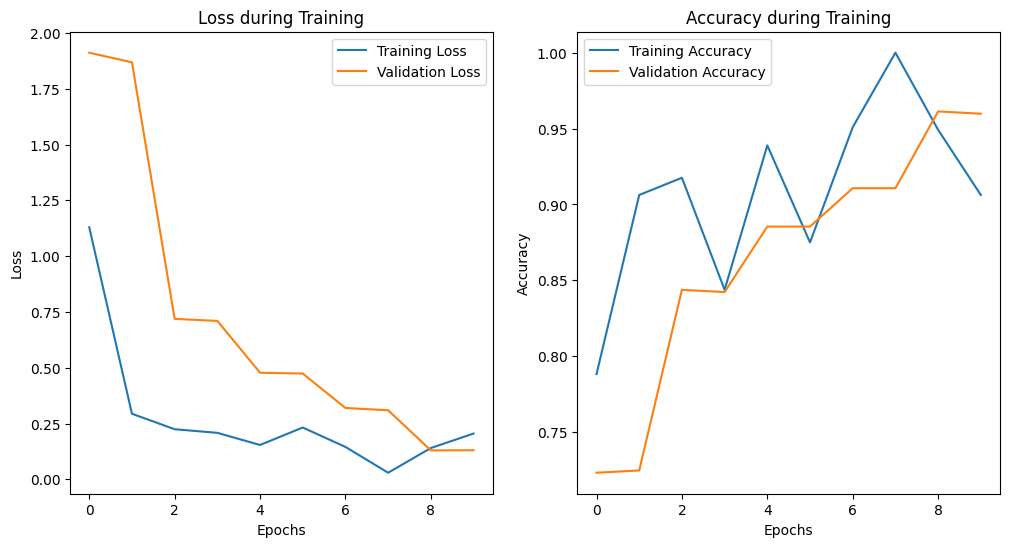

Modelo reentrenado guardado exitosamente.


In [ ]:
# ============================================
# Importar librerías necesarias
# ============================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

# ============================================
# Rutas del dataset y modelo
# ============================================
train_dir = "/content/drive/MyDrive/Colab Notebook - Dataset/Data-set-Fine-Tunnig/Nuevas fotos/train"
test_dir = "/content/drive/MyDrive/Colab Notebook - Dataset/Data-set-Fine-Tunnig/Nuevas fotos/test"
model_path = "/content/drive/MyDrive/Colab Notebook - Models/chanchitos_model2.keras"

# ============================================
# Cargar el modelo previamente entrenado
# ============================================
model = load_model(model_path)

# ============================================
# Ajustar las capas del modelo para fine-tuning
# ============================================
# Descongelamos solo las últimas 10 capas para reentrenarlas
for layer in model.layers[-5:]:
    layer.trainable = True

# Añadir Dropout y Regularización L2 en la capa densa (última capa entrenable)
for layer in model.layers:
    if isinstance(layer, Dense):  # Si es una capa Dense, agregamos regularización
        layer.kernel_regularizer = l2(0.01)

# ============================================
# Configurar los generadores de datos
# ============================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

# ============================================
# Configurar el callback de EarlyStopping
# ============================================
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# ============================================
# Recompilar el modelo con las nuevas capas y optimizador ajustado
# ============================================
new_optimizer = Adam(learning_rate=0.00003)  # Learning Rate menor para fine-tuning
model.compile(optimizer=new_optimizer, loss="binary_crossentropy", metrics=["accuracy"])

# ============================================
# Entrenar el modelo con fine-tuning
# ============================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[early_stopping],
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_steps=test_data.samples // test_data.batch_size
)

# ============================================
# Evaluar el modelo reentrenado
# ============================================
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# ============================================
# Visualizar la pérdida y precisión durante el entrenamiento
# ============================================
plt.figure(figsize=(12, 6))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Precisión
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy during Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# ============================================
# Guardar el modelo reentrenado
# ============================================
model.save("/content/drive/MyDrive/Colab Notebook - Models/fine_tuned_chanchitos_model_v5.keras")
print("Modelo reentrenado guardado exitosamente.")
